# 🍔 Zomato Delivery AI — Dual-Prediction System
### *Introductory Machine Learning for 1st Year B.Tech Students*

---

## 🎯 What are we building today?
When a customer orders food on Zomato, the system needs to answer two questions:

1. **ETA AI (Regression):** *How many minutes will this order take?*  
   $ightarrow$ Predicts an exact number (e.g. **24.5 minutes**). Model: **Linear Regression**.
2. **Late Delivery AI (Classification):** *Is this order going to be late (> 30 minutes)?*  
   $ightarrow$ Predicts a category (e.g. **Yes / No**). Model: **Logistic Regression**.

Both models learn from the **exact same order features** (distance, traffic, weather, etc.)!


## 1. Import Required Libraries
We only need three standard Python tools:
* `pandas`: for loading and inspecting tables
* `matplotlib.pyplot`: for simple, quick data charts
* `sklearn`: for splitting data and training models


In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline


## 2. Load the Dataset
Let's load `zomato_cleaned.csv` and view the first 5 rows.


In [2]:
df = pd.read_csv("zomato_cleaned.csv")
print(f"Total orders : {len(df):,}")
print(f"Total columns: {len(df.columns)}")
df.head()


Total orders : 42,444
Total columns: 10


,distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Road_traffic_density,Weather_conditions,Festival,Time_taken_min,late
0,10.28,36.0,4.2,2,3.0,Jam,Fog,No,46,1
1,6.24,21.0,4.7,1,1.0,High,Stormy,No,23,0
2,13.79,23.0,4.7,1,1.0,Medium,Sandstorms,No,21,0
3,2.93,34.0,4.3,0,0.0,Low,Sandstorms,No,20,0
4,19.40,24.0,4.7,1,1.0,Jam,Fog,No,41,1


## 3. Quick Data Exploration (EDA)
Let's check summary statistics and verify there are no missing values.


In [3]:
# Summary statistics for numeric features
df.describe().round(2)


,distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Time_taken_min,late
count,42444.00,42444.00,42444.00,42444.00,42444.00,42444.00,42444.00
mean,9.76,29.59,4.63,1.00,0.75,26.44,0.30
std,5.60,5.76,0.31,0.82,0.57,9.33,0.46
min,1.47,20.00,2.50,0.00,0.00,10.00,0.00
25%,4.66,25.00,4.50,0.00,0.00,19.00,0.00
50%,9.22,30.00,4.70,1.00,1.00,26.00,0.00
75%,13.68,35.00,4.90,2.00,1.00,33.00,1.00
max,20.97,39.00,5.00,2.00,3.00,54.00,1.00


In [4]:
# Check for missing values (Blanks)
df.isna().sum()


distance_km                0
Delivery_person_Age        0
Delivery_person_Ratings    0
Vehicle_condition          0
multiple_deliveries        0
Road_traffic_density       0
Weather_conditions         0
Festival                   0
Time_taken_min             0
late                       0
dtype: int64

### 3.1 Plot: Distribution of Delivery Times (Minimal Code)
💡 **Teaching Hint:** Notice that most orders take between 15 and 35 minutes, with a 30-minute late cutoff.


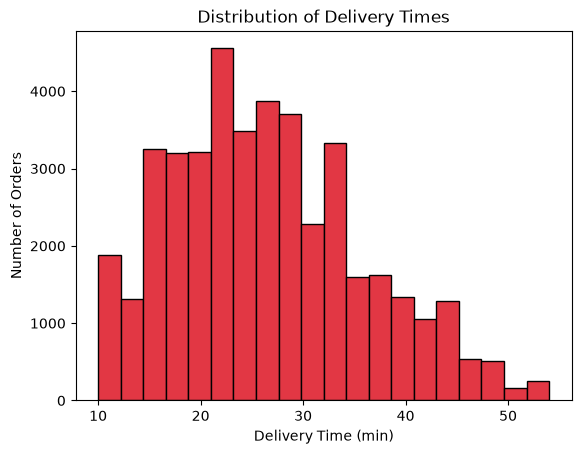

In [5]:
# Minimal 4-line histogram
plt.hist(df["Time_taken_min"], bins=20, color="#E23744", edgecolor="black")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Times")
plt.show()


### 3.2 Plot: Traffic vs. Delivery Time (Minimal Code)
💡 **Teaching Hint:** Ask students: *Does Jam traffic significantly increase delivery duration compared to Low traffic?*


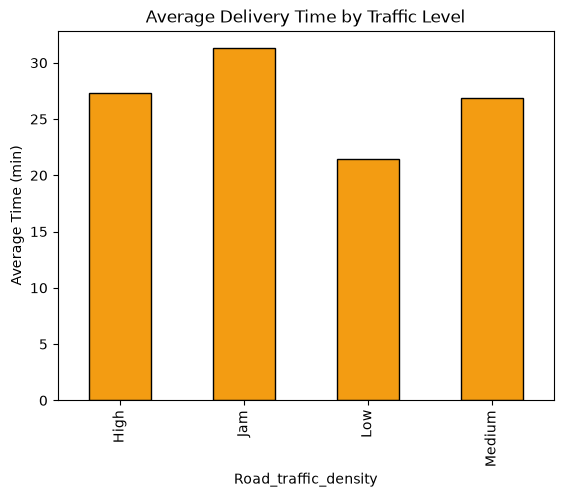

In [6]:
# Minimal 3-line bar plot
df.groupby("Road_traffic_density")["Time_taken_min"].mean().plot(kind="bar", color="#F39C12", edgecolor="black")
plt.ylabel("Average Time (min)")
plt.title("Average Delivery Time by Traffic Level")
plt.show()


## 4. Preprocessing: Words to Numbers (`pd.get_dummies`)
💡 **Teaching Hint (The Light Switch Analogy):**  
Machine learning equations only understand numbers, not text like `"High"` or `"Sunny"`.  
We use `pd.get_dummies()` to create **0/1 switch columns** for each category.


In [7]:
# Convert text categories into 0 and 1 columns
df = pd.get_dummies(df, columns=["Road_traffic_density", "Weather_conditions", "Festival"], dtype=int)
print(f"Columns after encoding: {len(df.columns)}")
df.head()


Columns after encoding: 19


,distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Time_taken_min,late,Road_traffic_density_High,Road_traffic_density_Jam,Road_traffic_density_Low,Road_traffic_density_Medium,Weather_conditions_Cloudy,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Festival_No,Festival_Yes
0,10.28,36.0,4.2,2,3.0,46,1,0,1,0,0,0,1,0,0,0,0,1,0
1,6.24,21.0,4.7,1,1.0,23,0,1,0,0,0,0,0,0,1,0,0,1,0
2,13.79,23.0,4.7,1,1.0,21,0,0,0,0,1,0,0,1,0,0,0,1,0
3,2.93,34.0,4.3,0,0.0,20,0,0,0,1,0,0,0,1,0,0,0,1,0
4,19.40,24.0,4.7,1,1.0,41,1,0,1,0,0,0,1,0,0,0,0,1,0


## 5. Separate Inputs ($X$) and Targets ($y$)
* **Inputs ($X$):** All columns except the answers.
* **Regression Target ($y_{\text{eta}}$):** Exact delivery time (`Time_taken_min`).
* **Classification Target ($y_{\text{late}}$):** Late delivery flag (`late`: 1 if > 30 min, else 0).

💡 **Teaching Hint:** We **never** include `Time_taken_min` in $X$ — that would be cheating (**Target Leakage**)!


In [8]:
X = df.drop(columns=["Time_taken_min", "late"])
y_eta = df["Time_taken_min"]
y_late = df["late"]

feature_columns = list(X.columns)
print("Number of input features:", len(feature_columns))


Number of input features: 17


## 6. Train / Test Split (The 80/20 Rule)
💡 **Teaching Hint (Mock Exam vs. Final Exam Analogy):**  
* **80% Training Data:** Study material for the model.
* **20% Testing Data:** Final exam questions the model has **never seen before** to test true learning!


In [9]:
X_train, X_test, y_eta_train, y_eta_test, y_late_train, y_late_test = train_test_split(
    X, y_eta, y_late, test_size=0.2, random_state=42
)

print(f"Training orders: {len(X_train):,}")
print(f"Testing orders : {len(X_test):,}")


Training orders: 33,955
Testing orders : 8,489


## 7. Model 1 — Linear Regression (Predicting Minutes)
Linear Regression fits a straight line ($y = mx + c$) to predict exact delivery duration.


In [10]:
# 1. Create the model
eta_model = LinearRegression()

# 2. Train the model on training data
eta_model.fit(X_train, y_eta_train)

# 3. Predict on unseen test data
eta_predictions = eta_model.predict(X_test)


### 7.1 Evaluate Linear Regression (MAE)
💡 **Teaching Hint:** Explain MAE in plain language:  
*On average, our prediction is off by only ~4.8 minutes!*


In [11]:
mae = mean_absolute_error(y_eta_test, eta_predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")


Mean Absolute Error (MAE): 4.81 minutes


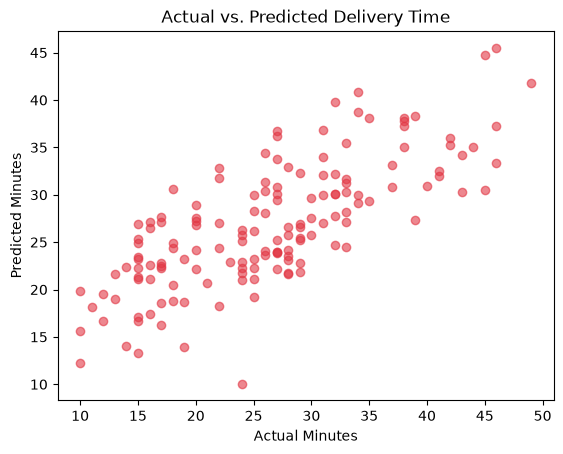

In [12]:
# Minimal 4-line scatter plot of actual vs predicted
plt.scatter(y_eta_test[:150], eta_predictions[:150], alpha=0.6, color="#E23744")
plt.xlabel("Actual Minutes")
plt.ylabel("Predicted Minutes")
plt.title("Actual vs. Predicted Delivery Time")
plt.show()


## 8. Model 2 — Logistic Regression (Predicting Late Risk)
Logistic Regression outputs an **S-curve (probability)** between 0% and 100% to classify whether an order will be late.


In [13]:
# 1. Create the classifier
late_model = LogisticRegression(max_iter=1000)

# 2. Train the model
late_model.fit(X_train, y_late_train)

# 3. Predict on unseen test data
late_predictions = late_model.predict(X_test)


### 8.1 Evaluate Logistic Regression (Accuracy & Confusion Matrix)
💡 **Teaching Hint:** An accuracy of ~88% means the model gets 88 out of every 100 predictions completely right!


In [14]:
accuracy = accuracy_score(y_late_test, late_predictions)
print(f"Accuracy: {accuracy * 100:.1f}%")


Accuracy: 88.3%


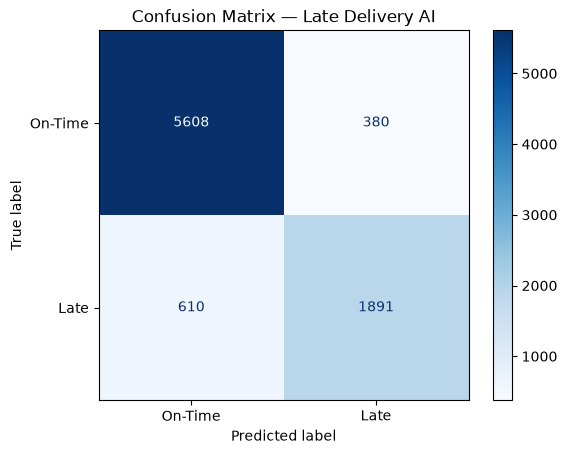

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_late_test, late_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On-Time", "Late"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Late Delivery AI")
plt.show()


## 9. Live Test on a Simulated Order
💡 **Teaching Hint:** Let's pretend a customer just ordered food right now. We pass their details to both models!


In [16]:
sample_order = pd.DataFrame([{
    "distance_km": 6.5,
    "Delivery_person_Age": 26,
    "Delivery_person_Ratings": 4.5,
    "Vehicle_condition": 1,
    "multiple_deliveries": 0,
    "Road_traffic_density": "High",
    "Weather_conditions": "Fog",
    "Festival": "No"
}])

# Align sample features with training columns
sample_encoded = pd.get_dummies(sample_order).reindex(columns=feature_columns, fill_value=0)

# Get both predictions
predicted_eta = eta_model.predict(sample_encoded)[0]
late_risk = late_model.predict_proba(sample_encoded)[0, 1]

print("🍔 --- Live Order Prediction Result --- 🍔")
print(f"Predicted ETA        : {predicted_eta:.1f} minutes")
print(f"Late Risk Probability: {late_risk * 100:.1f}%")


🍔 --- Live Order Prediction Result --- 🍔
Predicted ETA        : 27.8 minutes
Late Risk Probability: 51.7%


## 10. Save Models for the Streamlit Web App
We use Python's built-in `pickle` module to save our models so our interactive web app can load them.


In [17]:
os.makedirs("models", exist_ok=True)

with open("models/eta_linear_regression.pkl", "wb") as f:
    pickle.dump(eta_model, f)

with open("models/late_logistic_regression.pkl", "wb") as f:
    pickle.dump(late_model, f)

with open("models/model_info.pkl", "wb") as f:
    pickle.dump({"feature_cols": feature_columns, "late_threshold": 30}, f)

print("✅ Saved models to models/ folder successfully!")


✅ Saved models to models/ folder successfully!


## 11. Launch the Streamlit Web Application
In your terminal, run:

```bash
streamlit run app.py
```
This launches a browser window where students can drag sliders for distance, driver rating, weather, and traffic to test predictions interactively!
